In [743]:
import pandas as pd 
import shapely 
import geopandas as gpd
import scipy

# Data Loading

In [744]:
health = pd.read_csv('/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw/PLACES__Local_Data_for_Better_Health,_Census_Tract_Data,_2025_release_20260811.csv')
health #already filtered to dekalb and fulton 

,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2022,GA,Georgia,DeKalb,13089,13089022403,BRFSS,Prevention,Colorectal cancer screening among adults aged ...,%,...,70.9,78.1,"4,119","3,202",POINT (-84.3212938 33.7761539),13089022403,PREVENT,COLON_SCREEN,CrdPrv,Colorectal Cancer Screening
1,2023,GA,Georgia,DeKalb,13089,13089022203,BRFSS,Health-Related Social Needs,Received food stamps in the past 12 months amo...,%,...,6.6,10.2,"2,435","2,114",POINT (-84.2743533 33.7864692),13089022203,SOCLNEED,FOODSTAMP,CrdPrv,Food Stamps
2,2023,GA,Georgia,DeKalb,13089,13089023424,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,...,14.8,18.8,"5,366","4,111",POINT (-84.2876394 33.670735),13089023424,HLTHOUT,DIABETES,CrdPrv,Diabetes
3,2023,GA,Georgia,DeKalb,13089,13089023413,BRFSS,Health Risk Behaviors,Current cigarette smoking among adults,%,...,9.7,14.1,"3,482","2,889",POINT (-84.2382775 33.6919664),13089023413,RISKBEH,CSMOKING,CrdPrv,Current Cigarette Smoking
4,2023,GA,Georgia,DeKalb,13089,13089021223,BRFSS,Health Outcomes,Chronic obstructive pulmonary disease among ad...,%,...,2.0,3.1,"2,405","1,691",POINT (-84.3337899 33.9403169),13089021223,HLTHOUT,COPD,CrdPrv,COPD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21115,2023,GA,Georgia,Fulton,13121,13121011306,BRFSS,Disability,Any disability among adults,%,...,30.3,38.3,"3,371","2,481",POINT (-84.50339 33.6389921),13121011306,DISABLT,DISABILITY,CrdPrv,Any Disability
21116,2023,GA,Georgia,Fulton,13121,13121011627,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,...,9.1,12.0,"4,418","3,379",POINT (-84.1812816 34.0259786),13121011627,HLTHOUT,DIABETES,CrdPrv,Diabetes
21117,2023,GA,Georgia,Fulton,13121,13121011654,BRFSS,Health Outcomes,Arthritis among adults,%,...,17.4,21.8,"2,794","2,151",POINT (-84.3143145 34.075416),13121011654,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis
21118,2023,GA,Georgia,Fulton,13121,13121010529,BRFSS,Disability,Vision disability among adults,%,...,5.0,6.7,"6,290","4,729",POINT (-84.5088194 33.6027377),13121010529,DISABLT,VISION,CrdPrv,Vision Disability


In [745]:
courts = gpd.read_file('/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw/export (1).geojson')
courts #courts in Atlanta, must verify they fit within fulton and dekalb

,id,@id,access,addr:city,addr:housenumber,addr:postcode,addr:state,addr:street,attribution,barrier,...,name,nysgissam:nysaddresspointid,operator,quantity,smoking,source,sport,surface,wheelchair,geometry
0,way/28507812,way/28507812,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,paved,None,"POLYGON ((-84.29748 33.75718, -84.29748 33.756..."
1,way/40877278,way/40877278,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,concrete,None,"POLYGON ((-84.32096 33.75506, -84.32112 33.755..."
2,way/40877545,way/40877545,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.3374 33.75196, -84.3374 33.75173..."
3,way/40941425,way/40941425,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.3577 33.70411, -84.35754 33.7041..."
4,way/40941426,way/40941426,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.35754 33.70423, -84.35754 33.704..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,node/12215093688,node/12215093688,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.57022 33.6441)
346,node/12215093707,node/12215093707,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.56166 33.71072)
347,node/12215093733,node/12215093733,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.53101 33.72892)
348,node/13666936574,node/13666936574,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.39037 34.01343)


In [746]:
census = pd.read_json('/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw/censusgov.json')

census.columns = census.iloc[0] #assign first row of dataframe to columns
census = census[1:].reset_index(drop=True) #slice out the existing (now columns) row, keep the rest, and reset the index from 0 '

census.rename(columns={
    "B19013_001E": "median_household_income",
    "B17001_001E": "poverty_universe",
    "B17001_002E": "population_in_poverty",
    "B02001_001E": "race_universe",
    "B02001_002E": "pop_white_alone",
    "B02001_003E": "pop_black_alone",
    "B03003_003E": "pop_hispanic_or_latino",
    "B01003_001E": "total_population",
}, inplace=True) #rename the old variable codes to more distinguishable names 
census #already filtered to dekalb and fulton 

,NAME,median_household_income,population_in_poverty,poverty_universe,race_universe,pop_white_alone,pop_black_alone,pop_hispanic_or_latino,total_population,state,county,tract
0,Census Tract 201; DeKalb County; Georgia,181250,144,2128,2128,1948,26,193,2128,13,089,020100
1,Census Tract 202; DeKalb County; Georgia,93068,201,2068,2068,1556,76,70,2068,13,089,020200
2,Census Tract 203; DeKalb County; Georgia,175885,388,4548,4548,3357,314,339,4548,13,089,020300
3,Census Tract 204; DeKalb County; Georgia,188438,79,2714,2714,2244,95,119,2714,13,089,020400
4,Census Tract 205; DeKalb County; Georgia,99961,236,3546,3546,1901,1082,240,3546,13,089,020500
...,...,...,...,...,...,...,...,...,...,...,...,...
525,Census Tract 119.01; Fulton County; Georgia,55000,400,1477,1857,587,1088,184,1857,13,121,011901
526,Census Tract 119.02; Fulton County; Georgia,-666666666,382,1275,1275,428,602,93,1275,13,121,011902
527,Census Tract 120; Fulton County; Georgia,-666666666,2111,3587,3615,541,2741,145,3615,13,121,012000
528,Census Tract 123; Fulton County; Georgia,49855,227,2141,2175,669,1106,72,2175,13,121,012300


In [747]:
tracts = gpd.read_file('/Users/medhasubramaniyan/Desktop/GitHub_Repos/hoop-deserts-atl/data/raw/tl_2025_13_tract/tl_2025_13_tract.shp')

tracts = tracts[tracts['COUNTYFP'].isin(['121', '089'])]

tracts['COUNTYFP'].unique()
tracts.reset_index(drop=True,inplace=True)
tracts
# COUNTYFP for DeKalb County is 089 and for Fulton County is 121.

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,13,121,011417,13121011417,1400000US13121011417,114.17,Census Tract 114.17,G5020,S,7528526,92041,+34.0564788,-084.3693603,"POLYGON ((-84.39568 34.06267, -84.39566 34.062..."
1,13,121,011416,13121011416,1400000US13121011416,114.16,Census Tract 114.16,G5020,S,6618016,38422,+34.0649975,-084.3455864,"POLYGON ((-84.36105 34.07631, -84.36058 34.076..."
2,13,121,011421,13121011421,1400000US13121011421,114.21,Census Tract 114.21,G5020,S,3898568,38427,+34.0405266,-084.3328370,"POLYGON ((-84.34344 34.03709, -84.34324 34.038..."
3,13,121,006000,13121006000,1400000US13121006000,60,Census Tract 60,G5020,S,1566210,0,+33.7379429,-084.4390350,"POLYGON ((-84.44735 33.73454, -84.4472 33.7353..."
4,13,121,003600,13121003600,1400000US13121003600,36,Census Tract 36,G5020,S,393883,0,+33.7518731,-084.4029233,"POLYGON ((-84.40656 33.75127, -84.40656 33.751..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,13,089,021409,13089021409,1400000US13089021409,214.09,Census Tract 214.09,G5020,S,1041466,0,+33.8610663,-084.2957708,"POLYGON ((-84.30351 33.85028, -84.30295 33.850..."
526,13,089,023111,13089023111,1400000US13089023111,231.11,Census Tract 231.11,G5020,S,2337613,14379,+33.7574297,-084.2269034,"POLYGON ((-84.23328 33.77092, -84.23313 33.770..."
527,13,089,022010,13089022010,1400000US13089022010,220.10,Census Tract 220.10,G5020,S,1244723,19837,+33.8131970,-084.2297640,"POLYGON ((-84.23965 33.80943, -84.23908 33.810..."
528,13,089,023113,13089023113,1400000US13089023113,231.13,Census Tract 231.13,G5020,S,2039843,8918,+33.7771900,-084.2532758,"POLYGON ((-84.26725 33.77686, -84.26689 33.777..."


# Data Inspection

In [748]:
census.info()
census.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NAME                     530 non-null    object
 1   median_household_income  530 non-null    object
 2   population_in_poverty    530 non-null    object
 3   poverty_universe         530 non-null    object
 4   race_universe            530 non-null    object
 5   pop_white_alone          530 non-null    object
 6   pop_black_alone          530 non-null    object
 7   pop_hispanic_or_latino   530 non-null    object
 8   total_population         530 non-null    object
 9   state                    530 non-null    object
 10  county                   530 non-null    object
 11  tract                    530 non-null    object
dtypes: object(12)
memory usage: 49.8+ KB


,NAME,median_household_income,population_in_poverty,poverty_universe,race_universe,pop_white_alone,pop_black_alone,pop_hispanic_or_latino,total_population,state,county,tract
count,530,530,530,530,530,530,530,530,530,530,530,530
unique,530,506,393,506,501,467,485,336,501,1,2,529
top,Census Tract 201; DeKalb County; Georgia,-666666666,0,3115,2175,0,0,0,2175,13,121,980000
freq,1,14,10,3,3,16,5,32,3,530,327,2


In [749]:
census.isnull().sum() #theres no nulls, however -6666666 is used often (sentinel null )

0
NAME                       0
median_household_income    0
population_in_poverty      0
poverty_universe           0
race_universe              0
pop_white_alone            0
pop_black_alone            0
pop_hispanic_or_latino     0
total_population           0
state                      0
county                     0
tract                      0
dtype: int64

In [750]:
courts.info()
courts.describe()
courts.shape
courts.columns


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   id                           350 non-null    object  
 1   @id                          350 non-null    object  
 2   access                       68 non-null     object  
 3   addr:city                    2 non-null      object  
 4   addr:housenumber             2 non-null      object  
 5   addr:postcode                2 non-null      object  
 6   addr:state                   2 non-null      object  
 7   addr:street                  2 non-null      object  
 8   attribution                  1 non-null      object  
 9   barrier                      1 non-null      object  
 10  capacity                     1 non-null      object  
 11  covered                      3 non-null      object  
 12  fee                          4 non-null      object  
 1

Index(['id', '@id', 'access', 'addr:city', 'addr:housenumber', 'addr:postcode',
       'addr:state', 'addr:street', 'attribution', 'barrier', 'capacity',
       'covered', 'fee', 'hoops', 'indoor', 'layer', 'leisure', 'lit',
       'location', 'name', 'nysgissam:nysaddresspointid', 'operator',
       'quantity', 'smoking', 'source', 'sport', 'surface', 'wheelchair',
       'geometry'],
      dtype='object')

In [751]:
courts.isnull().sum() # lots of nulls (None) abscence of values 
courts[courts['access'].isnull()]

,id,@id,access,addr:city,addr:housenumber,addr:postcode,addr:state,addr:street,attribution,barrier,...,name,nysgissam:nysaddresspointid,operator,quantity,smoking,source,sport,surface,wheelchair,geometry
0,way/28507812,way/28507812,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,paved,None,"POLYGON ((-84.29748 33.75718, -84.29748 33.756..."
1,way/40877278,way/40877278,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,concrete,None,"POLYGON ((-84.32096 33.75506, -84.32112 33.755..."
2,way/40877545,way/40877545,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.3374 33.75196, -84.3374 33.75173..."
3,way/40941425,way/40941425,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.3577 33.70411, -84.35754 33.7041..."
4,way/40941426,way/40941426,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,"POLYGON ((-84.35754 33.70423, -84.35754 33.704..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,node/12215093688,node/12215093688,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.57022 33.6441)
346,node/12215093707,node/12215093707,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.56166 33.71072)
347,node/12215093733,node/12215093733,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.53101 33.72892)
348,node/13666936574,node/13666936574,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,basketball,None,None,POINT (-84.39037 34.01343)


In [752]:
tracts.info()
tracts.describe()
tracts.shape
tracts.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   530 non-null    object  
 1   COUNTYFP  530 non-null    object  
 2   TRACTCE   530 non-null    object  
 3   GEOID     530 non-null    object  
 4   GEOIDFQ   530 non-null    object  
 5   NAME      530 non-null    object  
 6   NAMELSAD  530 non-null    object  
 7   MTFCC     530 non-null    object  
 8   FUNCSTAT  530 non-null    object  
 9   ALAND     530 non-null    int64   
 10  AWATER    530 non-null    int64   
 11  INTPTLAT  530 non-null    object  
 12  INTPTLON  530 non-null    object  
 13  geometry  530 non-null    geometry
dtypes: geometry(1), int64(2), object(11)
memory usage: 58.1+ KB


Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry'],
      dtype='object')

In [753]:
tracts.isnull().sum() # no nuls 
tracts
# STATEFP, COUNTYFP, TRACTCE, GEOID, GEOIDFQ

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,13,121,011417,13121011417,1400000US13121011417,114.17,Census Tract 114.17,G5020,S,7528526,92041,+34.0564788,-084.3693603,"POLYGON ((-84.39568 34.06267, -84.39566 34.062..."
1,13,121,011416,13121011416,1400000US13121011416,114.16,Census Tract 114.16,G5020,S,6618016,38422,+34.0649975,-084.3455864,"POLYGON ((-84.36105 34.07631, -84.36058 34.076..."
2,13,121,011421,13121011421,1400000US13121011421,114.21,Census Tract 114.21,G5020,S,3898568,38427,+34.0405266,-084.3328370,"POLYGON ((-84.34344 34.03709, -84.34324 34.038..."
3,13,121,006000,13121006000,1400000US13121006000,60,Census Tract 60,G5020,S,1566210,0,+33.7379429,-084.4390350,"POLYGON ((-84.44735 33.73454, -84.4472 33.7353..."
4,13,121,003600,13121003600,1400000US13121003600,36,Census Tract 36,G5020,S,393883,0,+33.7518731,-084.4029233,"POLYGON ((-84.40656 33.75127, -84.40656 33.751..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,13,089,021409,13089021409,1400000US13089021409,214.09,Census Tract 214.09,G5020,S,1041466,0,+33.8610663,-084.2957708,"POLYGON ((-84.30351 33.85028, -84.30295 33.850..."
526,13,089,023111,13089023111,1400000US13089023111,231.11,Census Tract 231.11,G5020,S,2337613,14379,+33.7574297,-084.2269034,"POLYGON ((-84.23328 33.77092, -84.23313 33.770..."
527,13,089,022010,13089022010,1400000US13089022010,220.10,Census Tract 220.10,G5020,S,1244723,19837,+33.8131970,-084.2297640,"POLYGON ((-84.23965 33.80943, -84.23908 33.810..."
528,13,089,023113,13089023113,1400000US13089023113,231.13,Census Tract 231.13,G5020,S,2039843,8918,+33.7771900,-084.2532758,"POLYGON ((-84.26725 33.77686, -84.26689 33.777..."


In [754]:
health.info()
health.describe()
health.shape
health.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21120 entries, 0 to 21119
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        21120 non-null  int64  
 1   StateAbbr                   21120 non-null  object 
 2   StateDesc                   21120 non-null  object 
 3   CountyName                  21120 non-null  object 
 4   CountyFIPS                  21120 non-null  int64  
 5   LocationName                21120 non-null  int64  
 6   DataSource                  21120 non-null  object 
 7   Category                    21120 non-null  object 
 8   Measure                     21120 non-null  object 
 9   Data_Value_Unit             21120 non-null  object 
 10  Data_Value_Type             21120 non-null  object 
 11  Data_Value                  21120 non-null  float64
 12  Data_Value_Footnote_Symbol  0 non-null      float64
 13  Data_Value_Footnote         0 n

Index(['Year', 'StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS',
       'LocationName', 'DataSource', 'Category', 'Measure', 'Data_Value_Unit',
       'Data_Value_Type', 'Data_Value', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit',
       'TotalPopulation', 'TotalPop18plus', 'Geolocation', 'LocationID',
       'CategoryID', 'MeasureId', 'DataValueTypeID', 'Short_Question_Text'],
      dtype='object')

# Data Cleaning

## Dtype cleanup/correction + Null Handling

In [755]:
# Cast the Census internal point to float
tracts['INTPTLAT'] = tracts['INTPTLAT'].astype(float)   # '+34.2599764'  -> 34.2599764
tracts['INTPTLON'] = tracts['INTPTLON'].astype(float)   # '-084.2447452' -> -84.2447452

# Drop columns that carry no information for this analysis.
tracts = tracts.drop(columns=['GEOIDFQ', 'MTFCC', 'FUNCSTAT'])

tracts.dtypes



STATEFP       object
COUNTYFP      object
TRACTCE       object
GEOID         object
NAME          object
NAMELSAD      object
ALAND          int64
AWATER         int64
INTPTLAT     float64
INTPTLON     float64
geometry    geometry
dtype: object

In [756]:
# Identifiers stay strings — leading zeros are meaningful ('089', not 89).
id_cols = ['state', 'county', 'tract']
census[id_cols] = census[id_cols].astype('string')
census['NAME'] = census['NAME'].astype('string')
# Using .astype(str) or .astype('str') converts missing values into the literal text string 'nan', 
# while .astype('string') preserves them as true missing values (<NA>)


# Everything else is a count or dollar amount
numerics = []
for col in census.columns:
    if col not in id_cols + ['NAME', 'GEOID']:
        numerics.append(col)
#if the  column is not in ['state', 'county', 'tract', 'NAME', 'GEOID'] add it to the numeric column

census[numerics] = census[numerics].apply(pd.to_numeric, errors='coerce')


# The Census API encodes "no estimate available" as -666666666, not null.
# pd.to_numeric parses those into valid negative numbers, so mask them
census[numerics] = census[numerics].mask(census[numerics] < 0)
#.mask() says "Wherever the condition is True, replace the value with NaN." 

census['GEOID'] = census['state'] + census['county'] + census['tract']

assert census['GEOID'].str.len().eq(11).all(), "GEOID must be 11 chars"
#  statement is used to test conditions in your code. If the condition evaluates to True, the code continues running. 
# If it evaluates to False, Python raises an AssertionError and halts execution. 
# .eq() means equals, so if str.len() equals 11 
#.all() returns True if all values we are checking result to true 
census[numerics].isna().sum()


0
median_household_income    14
population_in_poverty       0
poverty_universe            0
race_universe               0
pop_white_alone             0
pop_black_alone             0
pop_hispanic_or_latino      0
total_population            0
dtype: int64

In [757]:
# LocationID arrives as int64 (13089022403) but tracts.GEOID is a string.
# Merging across that type mismatch returns ZERO rows and raises no error.
health['GEOID'] = health['LocationID'].astype(str).str.zfill(11)
health['CountyFIPS'] = health['CountyFIPS'].astype(str).str.zfill(5)

# Thousands separators made this object; strip them before casting.
health['TotalPopulation'] = pd.to_numeric(
    health['TotalPopulation'].astype(str).str.replace(',', '', regex=False),
    errors='coerce',
)
health['TotalPop18plus'] = pd.to_numeric(
    health['TotalPop18plus'].astype(str).str.replace(',', '', regex=False),
    errors='coerce',
)

#both are 100% null
health.drop(columns=['Data_Value_Footnote_Symbol', 'Data_Value_Footnote'], inplace=True)

# Low-cardinality repeated strings -> category (40 measures across 21k rows).
for col in ['StateAbbr', 'CountyName', 'MeasureId', 'Category', 'Measure', 'DataValueTypeID']:
    health[col] = health[col].astype('category')

assert health['GEOID'].str.len().eq(11).all()
health[['GEOID', 'CountyFIPS', 'TotalPopulation', 'MeasureId', 'TotalPop18plus']].dtypes
health.isna().sum()


Year                     0
StateAbbr                0
StateDesc                0
CountyName               0
CountyFIPS               0
LocationName             0
DataSource               0
Category                 0
Measure                  0
Data_Value_Unit          0
Data_Value_Type          0
Data_Value               0
Low_Confidence_Limit     0
High_Confidence_Limit    0
TotalPopulation          0
TotalPop18plus           0
Geolocation              0
LocationID               0
CategoryID               0
MeasureId                0
DataValueTypeID          0
Short_Question_Text      0
GEOID                    0
dtype: int64

In [758]:

# 'hoops' is a count stored as an OSM string tag; 'layer' is a signed int.
courts['hoops'] = pd.to_numeric(courts['hoops'], errors='coerce').astype('Int64')


if 'layer' in courts.columns:
    courts['layer'] = pd.to_numeric(courts['layer'], errors='coerce').astype('Int64')
#if there is a column called layer in the df do this conversion 


# Every other OSM tag is free-text and stays object. They are sparsely populated:
courts[['access', 'hoops', 'surface', 'lit', 'name','layer']].notna().sum()


access      68
hoops      127
surface     37
lit         22
name         5
layer        2
dtype: int64

## 

## Handling Geographic Data
tracts —  Each tract is a shape covering an area of Fulton/DeKalb.

courts — court shapes.. Some are polygons (the painted court outline, from OSM way/), some are single points (node/).

In [ ]:
# align CRS
print("courts:", courts.crs)   # EPSG:4326 (WGS84, OSM export)
print("tracts:", tracts.crs)   # EPSG:4269 (NAD83, TIGER shapefile)

courts = courts.to_crs(tracts.crs)
assert courts.crs == tracts.crs


courts: EPSG:4326
tracts: EPSG:4269


In [ ]:
# centroids pre join 
# 341 polygons + 9 points. Collapse to one point each: a polygon straddling a
# tract boundary is ambiguous under 'within' and drops out silently. Also, at
# county zoom a court polygon is ~1 pixel, so plotting raw geometry looks like
# almost no courts exist — that is a rendering artifact, not sparse data.
print(courts.geom_type.value_counts())
courts['geometry'] = courts.geometry.centroid


Polygon    341
Point        9
Name: count, dtype: int64


/var/folders/cm/46nnvpl978b_vb10b1dp7rp80000gn/T/ipykernel_4055/3832168850.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  courts['geometry'] = courts.geometry.centroid


In [ ]:
# spatial filter 
# The Overpass query matched county NAME, so it caught every Fulton/DeKalb in
# the US (Indianapolis, Missouri, Illinois, Ohio). No bounding-box filter is
# needed: the tract polygons ARE the study area, so how='inner' drops
# everything outside them by construction.
n_before = len(courts)
courts = gpd.sjoin(courts, tracts[['GEOID', 'NAMELSAD', 'geometry']],
                   how='inner', predicate='within')
courts = courts.drop(columns='index_right')
print(f'{n_before} nationwide -> {len(courts)} in Fulton + DeKalb')


350 nationwide -> 191 in Fulton + DeKalb


In [ ]:
# validation
assert courts.GEOID.isin(tracts.GEOID).all()
assert not courts['id'].duplicated().any()
assert (courts.geom_type == 'Point').all()
assert courts.geometry.notna().all() and not courts.geometry.is_empty.any()

# Bounds sit inside the tract bounds — confirms the out-of-state courts are gone.
minx, miny, maxx, maxy = tracts.total_bounds
cminx, cminy, cmaxx, cmaxy = courts.total_bounds
assert minx <= cminx and cmaxx <= maxx and miny <= cminy and cmaxy <= maxy

print(f'{len(courts)} courts across {courts.GEOID.nunique()} of {len(tracts)} tracts')
print(f'{len(tracts) - courts.GEOID.nunique()} tracts have no court')
courts[['access', 'hoops', 'surface', 'lit', 'name']].notna().sum()


191 courts across 121 of 530 tracts
409 tracts have no court


access     33
hoops      47
surface    22
lit        18
name        4
dtype: int64

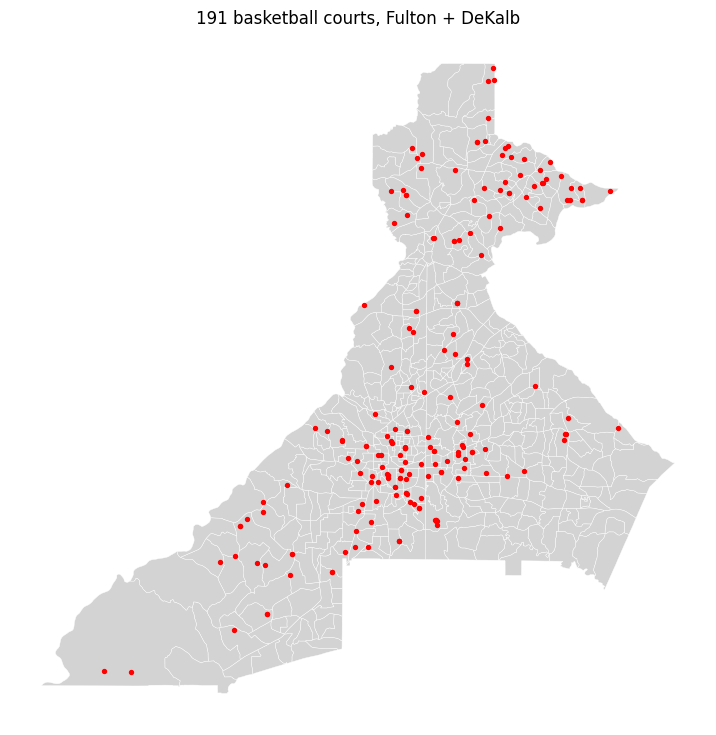

In [ ]:
# viz
ax = tracts.plot(figsize=(9, 9), color='lightgrey', edgecolor='white', linewidth=0.3)
courts.plot(ax=ax, color='red', markersize=8)
ax.set_title(f'{len(courts)} basketball courts, Fulton + DeKalb')
ax.set_axis_off()
plt.show()


## Pivot health table

In [765]:
one = health[health['GEOID'] == '13089022403']
print(len(one))
one[['GEOID', 'Year', 'MeasureId', 'DataValueTypeID', 'Data_Value']].head(20)


40


,GEOID,Year,MeasureId,DataValueTypeID,Data_Value
0,13089022403,2022,COLON_SCREEN,CrdPrv,74.5
144,13089022403,2023,COGNITION,CrdPrv,7.7
296,13089022403,2023,INDEPLIVE,CrdPrv,4.2
420,13089022403,2023,MOBILITY,CrdPrv,7.3
903,13089022403,2023,SHUTUTILITY,CrdPrv,3.0
925,13089022403,2023,BPHIGH,CrdPrv,31.3
1155,13089022403,2023,EMOTIONSPT,CrdPrv,15.4
1575,13089022403,2023,LPA,CrdPrv,12.3
1591,13089022403,2023,HEARING,CrdPrv,5.4
2205,13089022403,2023,COPD,CrdPrv,3.6


In [766]:
print(health.Year.unique())
print(health.DataValueTypeID.unique())
print(health.MeasureId.nunique(), "distinct measures")

# The real question: how many rows per tract+measure?
health.groupby(['GEOID', 'MeasureId'], observed=True).size().value_counts()


[2022 2023]
['CrdPrv']
Categories (1, object): ['CrdPrv']
40 distinct measures


1    21120
Name: count, dtype: int64

In [767]:
h = health[(health.Year == 2023) & (health.DataValueTypeID == 'CrdPrv')].copy()

# Now verify it: every tract+measure pair should appear exactly once.
assert h.groupby(['GEOID', 'MeasureId'], observed=True).size().max() == 1


In [768]:
toy = h[h.GEOID == h.GEOID.iloc[0]][['GEOID', 'MeasureId', 'Data_Value']].head(3)
print("BEFORE (long):")
print(toy)

print("\nAFTER (wide):")
print(toy.pivot_table(index='GEOID', columns='MeasureId', values='Data_Value', observed=True))


BEFORE (long):
           GEOID  MeasureId  Data_Value
1    13089022203  FOODSTAMP         8.3
38   13089022203  INDEPLIVE         6.3
146  13089022203     BPHIGH        33.4

AFTER (wide):
MeasureId    BPHIGH  FOODSTAMP  INDEPLIVE
GEOID                                    
13089022203    33.4        8.3        6.3


In [770]:
health_wide = h.pivot_table(index='GEOID', columns='MeasureId',
                            values='Data_Value', observed=True)
health_wide.columns.name = None      # drop the leftover 'MeasureId' label
health_wide = health_wide.reset_index()

print(health_wide.shape)             # expect ~530 rows x (1 + n_measures)
assert health_wide.GEOID.is_unique

health_wide[['GEOID', 'OBESITY', 'LPA', 'MHLTH']].head(20)


(528, 36)


,GEOID,OBESITY,LPA,MHLTH
0,13089020100,24.1,13.2,13.1
1,13089020200,23.1,11.9,13.0
2,13089020300,26.0,13.7,13.7
3,13089020400,23.8,11.2,13.4
4,13089020500,27.6,15.7,15.4
5,13089020600,30.7,17.2,17.1
6,13089020700,28.2,15.6,16.0
7,13089020801,26.0,13.6,13.7
8,13089020802,30.3,18.5,15.6
9,13089020901,27.5,15.1,14.4
